# Define constants

In [1]:
import librosa
from os import path

FEATURES_PATH = path.normpath("../../features/opus-training.npz")
MODEL_SAVE_PATH = path.normpath("../../models/model-bn-c64-c128-c256-c256-d256.keras")

# Least audio duration
AUDIO_MIN_DURATION = 2 # seconds
AUDIO_SAMPLE_RATE = 48_000

# How many frames to skip in each samples
CQT_HOP_LENGTH = 512

# Bin numbers based on octaves for input
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36

# Frame size for input uses the least frames
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)

# Starts from note
CQT_FMIN = librosa.note_to_hz('C1')

In [2]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model(MODEL_SAVE_PATH)
with np.load(FEATURES_PATH) as data:
  features = data['features']
  labels = data['labels']

print("Features and labels loaded successfully.")

2026-05-14 22:39:31.842368: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-14 22:39:31.842412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-14 22:39:31.858800: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-14 22:39:31.893225: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-14 22:39:32.936343: W tensorflow/compiler/tf2

Features and labels loaded successfully.


# Setup

In [3]:
import gc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

def stretch_features_to_frames(feature_array, target_frames=CQT_FEATURE_FRAMES):
    feature_array = np.asarray(feature_array)

    if feature_array.ndim == 2:
        source_frames = feature_array.shape[1]
        if source_frames == target_frames:
            return feature_array.astype(np.float32, copy=False)
        if source_frames == 1:
            return np.repeat(feature_array, target_frames, axis=1).astype(np.float32, copy=False)

        source_positions = np.linspace(0.0, 1.0, source_frames)
        target_positions = np.linspace(0.0, 1.0, target_frames)
        stretched_rows = [
            np.interp(target_positions, source_positions, row)
            for row in feature_array
        ]
        return np.asarray(stretched_rows, dtype=np.float32)

    if feature_array.ndim == 3:
        return np.stack(
            [stretch_features_to_frames(sample, target_frames) for sample in feature_array],
            axis=0,
        )

    raise ValueError(f"Expected a 2D or 3D feature array, got shape {feature_array.shape}")

def evaluate_model_on_features(model, feature_batch, labels, evaluation_name):
    label_encoder = LabelEncoder()
    label_encoder.fit(labels)

    encoded_labels = label_encoder.transform(labels)
    stretched_features = None
    features_reshaped = None
    predictions = None
    predicted_classes = None

    try:
        stretched_features = stretch_features_to_frames(feature_batch, CQT_FEATURE_FRAMES)
        features_reshaped = np.expand_dims(stretched_features, axis=-1)
        predictions = model.predict(features_reshaped, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)

        accuracy = accuracy_score(encoded_labels, predicted_classes)
        report_df = pd.DataFrame(
            classification_report(
                encoded_labels,
                predicted_classes,
                target_names=label_encoder.classes_,
                output_dict=True,
                zero_division=0,
            )
        ).T
        confusion_df = pd.DataFrame(
            confusion_matrix(encoded_labels, predicted_classes),
            index=label_encoder.classes_,
            columns=label_encoder.classes_,
        )

        summary_df = pd.DataFrame(
            [{
                "evaluation": evaluation_name,
                "input_frames": feature_batch.shape[-1],
                "target_frames": stretched_features.shape[-1],
                "num_samples": len(labels),
                "accuracy": accuracy,
                "macro_f1": report_df.loc["macro avg", "f1-score"],
                "weighted_f1": report_df.loc["weighted avg", "f1-score"],
            }]
        )

        return {
            "summary": summary_df,
            "report": report_df,
            "confusion_matrix": confusion_df,
        }
    finally:
        del predictions
        del predicted_classes
        del features_reshaped
        del stretched_features
        del encoded_labels
        gc.collect()

def plot_confusion_matrix(confusion_df, title):
    figure, axis = plt.subplots(figsize=(10, 10))
    sns.heatmap(
        confusion_df,
        annot=True,
        annot_kws={"size": 8},
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    return figure

def evaluate_frames(frames=CQT_FEATURE_FRAMES):
    this_features = features[:, :, :frames]
    this_results = evaluate_model_on_features(model, this_features, labels, f"{frames} frames")
    display(this_results["summary"].round(4))
    display(this_results["report"].round(4))
    plot_confusion_matrix(this_results["confusion_matrix"], f"{frames} frames evaluation")
    return this_results

# Evaluation

## Original 188 frames

2026-05-14 22:39:43.301008: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1169510400 exceeds 10% of free system memory.
2026-05-14 22:39:44.781666: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1169510400 exceeds 10% of free system memory.
2026-05-14 22:39:46.035759: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-14 22:39:46.059434: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 333.25MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-05-14 22:39:46.059484: W tensorflow/core/kernels/gpu_utils.cc:54] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be pr

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_f1,weighted_f1
0,188 frames,188,188,7200,1.0,1.0,1.0


,precision,recall,f1-score,support
A#_diminished_4,1.0,1.0,1.0,200.0
A#_major_4,1.0,1.0,1.0,200.0
A#_minor_4,1.0,1.0,1.0,200.0
A_diminished_4,1.0,1.0,1.0,200.0
A_major_4,1.0,1.0,1.0,200.0
A_minor_4,1.0,1.0,1.0,200.0
B_diminished_4,1.0,1.0,1.0,200.0
B_major_4,1.0,1.0,1.0,200.0
B_minor_4,1.0,1.0,1.0,200.0
C#_diminished_4,1.0,1.0,1.0,200.0


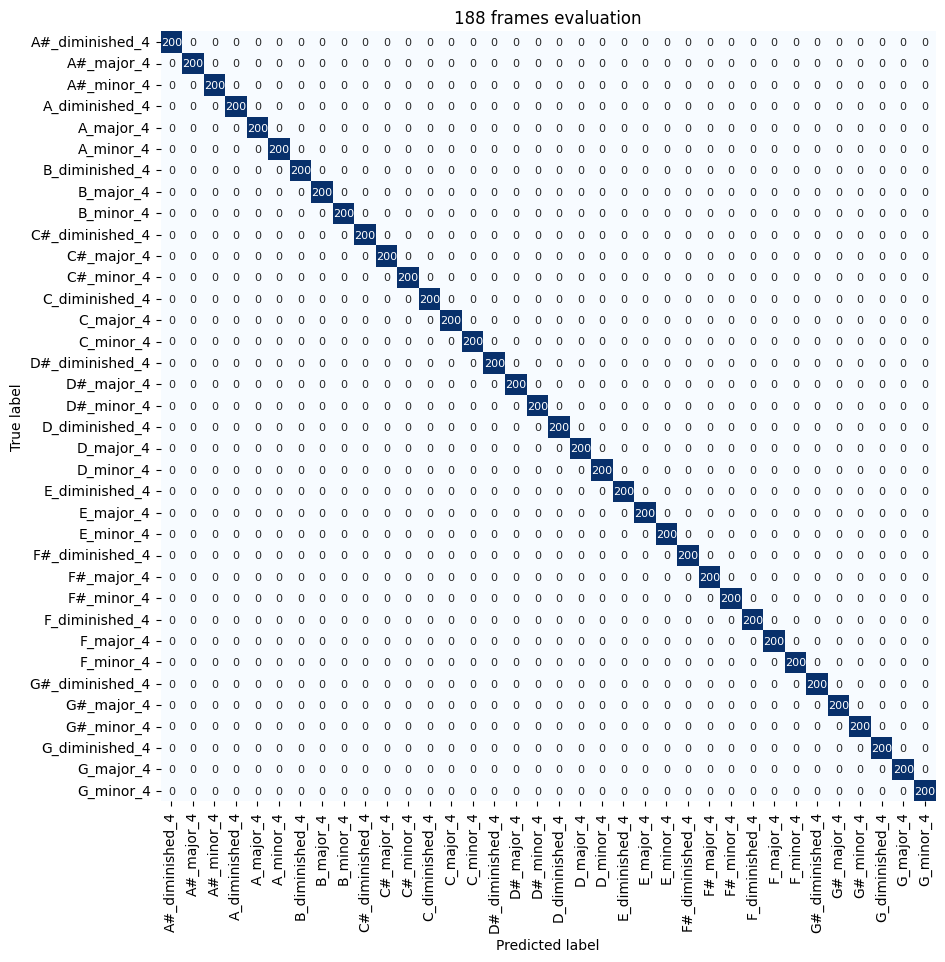

In [4]:
original_results = evaluate_frames()

## 150 frames

2026-05-14 22:40:07.820914: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1169510400 exceeds 10% of free system memory.
2026-05-14 22:40:09.041208: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1169510400 exceeds 10% of free system memory.


,evaluation,input_frames,target_frames,num_samples,accuracy,macro_f1,weighted_f1
0,150 frames,150,188,7200,1.0,1.0,1.0


,precision,recall,f1-score,support
A#_diminished_4,1.0,1.0,1.0,200.0
A#_major_4,1.0,1.0,1.0,200.0
A#_minor_4,1.0,1.0,1.0,200.0
A_diminished_4,1.0,1.0,1.0,200.0
A_major_4,1.0,1.0,1.0,200.0
A_minor_4,1.0,1.0,1.0,200.0
B_diminished_4,1.0,1.0,1.0,200.0
B_major_4,1.0,1.0,1.0,200.0
B_minor_4,1.0,1.0,1.0,200.0
C#_diminished_4,1.0,1.0,1.0,200.0


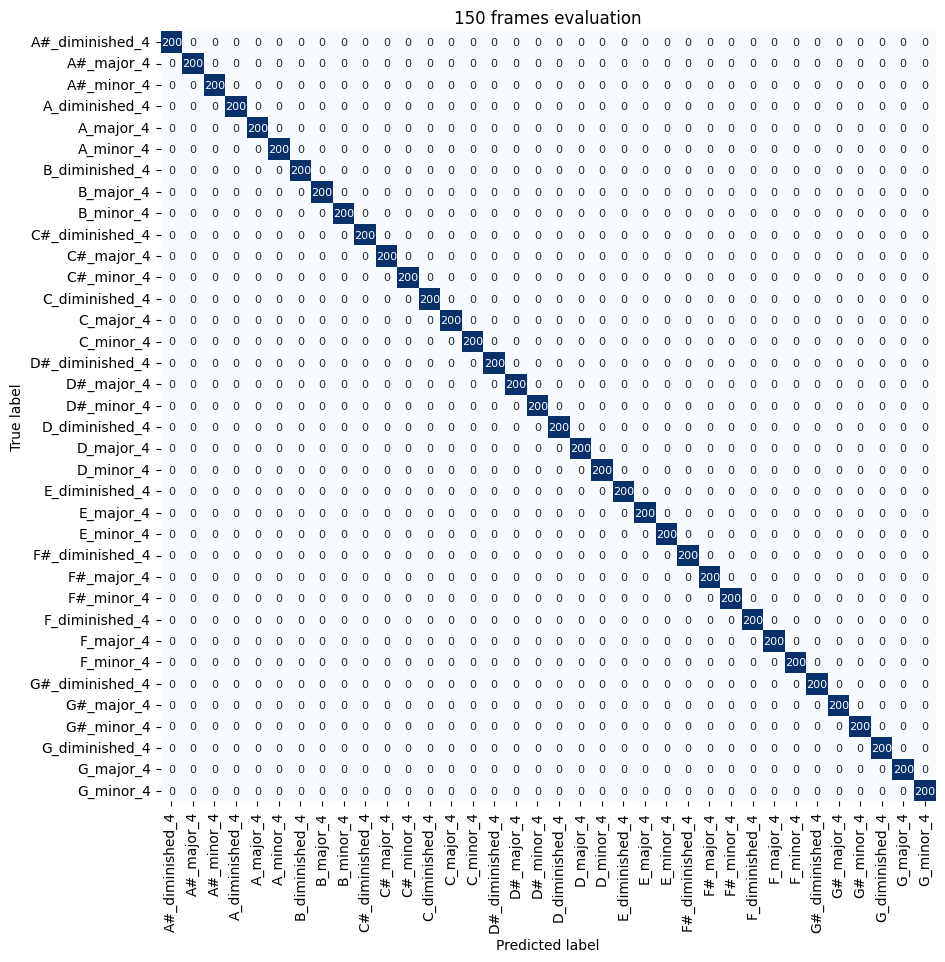

In [5]:
results_150 = evaluate_frames(150)

## 100 frames

2026-05-14 22:40:27.335815: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1169510400 exceeds 10% of free system memory.


,evaluation,input_frames,target_frames,num_samples,accuracy,macro_f1,weighted_f1
0,100 frames,100,188,7200,0.9972,0.9972,0.9972


,precision,recall,f1-score,support
A#_diminished_4,1.0000,0.9850,0.9924,200.0000
A#_major_4,1.0000,1.0000,1.0000,200.0000
A#_minor_4,0.9852,1.0000,0.9926,200.0000
A_diminished_4,1.0000,1.0000,1.0000,200.0000
A_major_4,1.0000,1.0000,1.0000,200.0000
A_minor_4,1.0000,1.0000,1.0000,200.0000
B_diminished_4,1.0000,0.9850,0.9924,200.0000
B_major_4,1.0000,1.0000,1.0000,200.0000
B_minor_4,1.0000,1.0000,1.0000,200.0000
C#_diminished_4,1.0000,0.9800,0.9899,200.0000


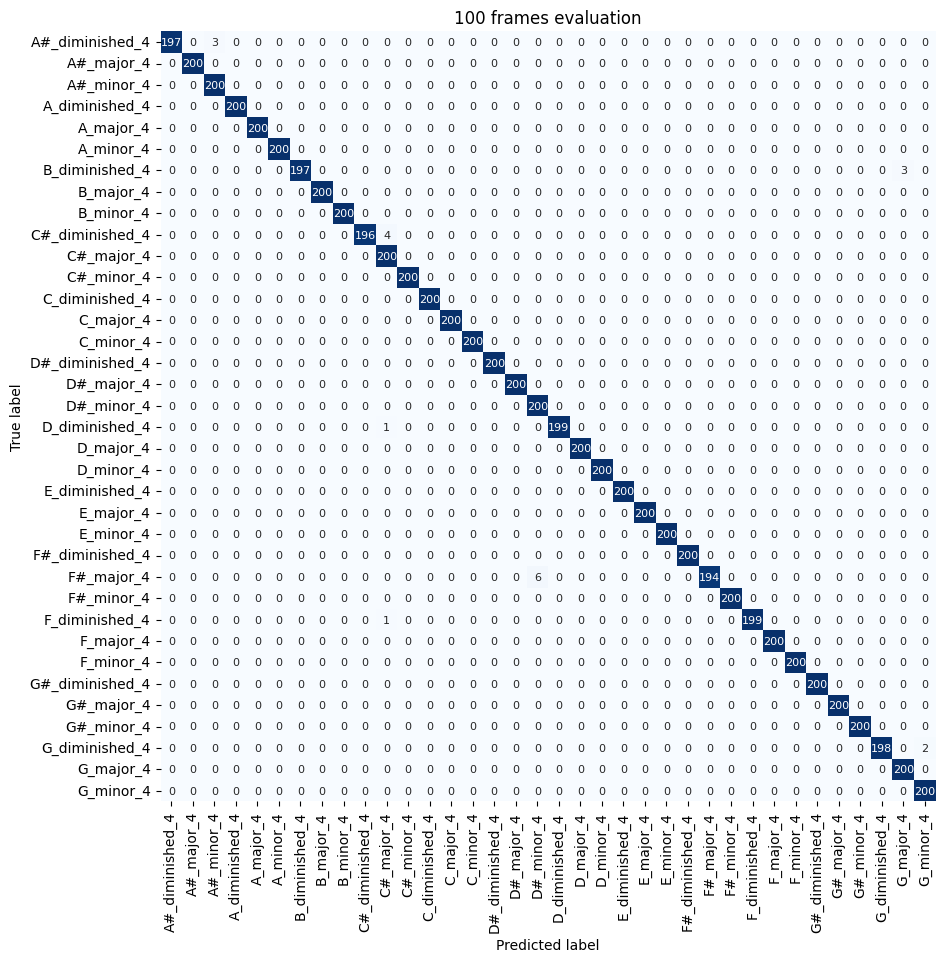

In [6]:
results_100 = evaluate_frames(100)

## 50 frames

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_f1,weighted_f1
0,50 frames,50,188,7200,0.7488,0.7405,0.7405


,precision,recall,f1-score,support
A#_diminished_4,1.0000,0.5200,0.6842,200.0000
A#_major_4,0.8571,0.7800,0.8168,200.0000
A#_minor_4,0.8241,0.8200,0.8221,200.0000
A_diminished_4,0.9484,0.7350,0.8282,200.0000
A_major_4,0.9127,0.5750,0.7055,200.0000
A_minor_4,0.7982,0.8700,0.8325,200.0000
B_diminished_4,0.8176,0.6950,0.7514,200.0000
B_major_4,0.9886,0.8700,0.9255,200.0000
B_minor_4,0.7299,1.0000,0.8439,200.0000
C#_diminished_4,0.9236,0.6650,0.7733,200.0000


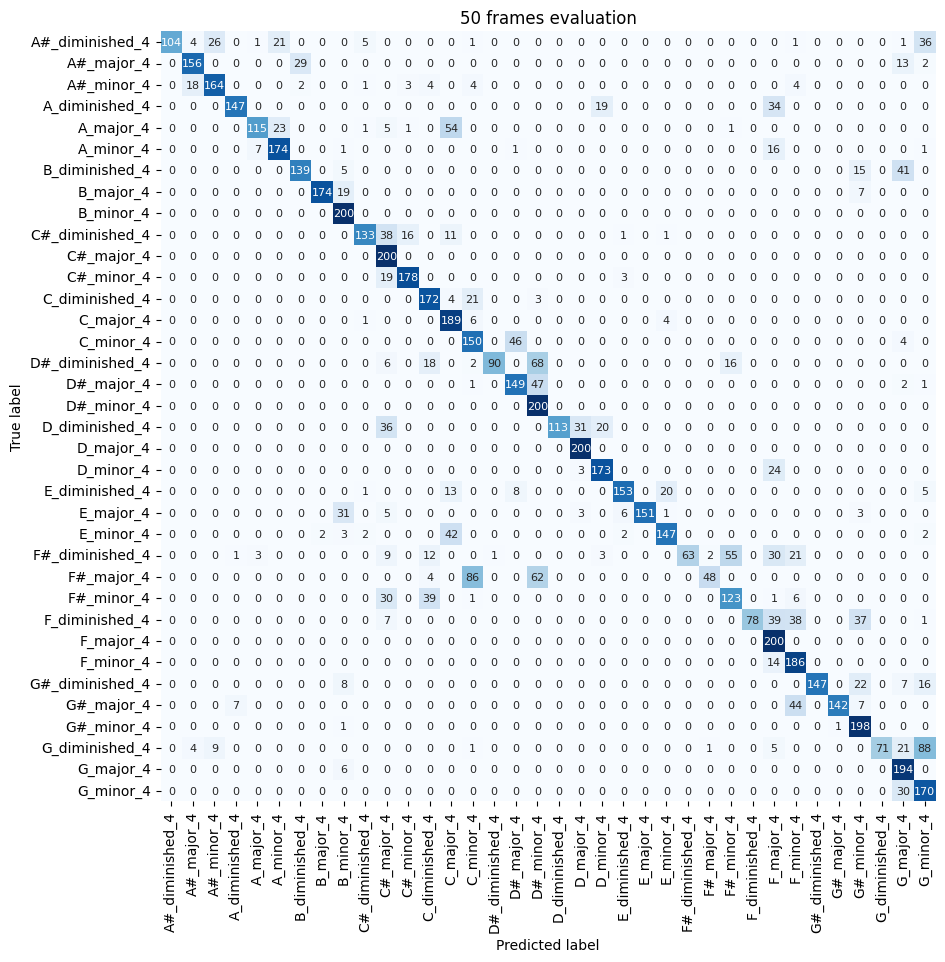

In [7]:
results_50 = evaluate_frames(50)

## 25 frames

,evaluation,input_frames,target_frames,num_samples,accuracy,macro_f1,weighted_f1
0,25 frames,25,188,7200,0.314,0.2673,0.2673


,precision,recall,f1-score,support
A#_diminished_4,0.7273,0.040,0.0758,200.000
A#_major_4,0.5041,0.305,0.3801,200.000
A#_minor_4,0.4776,0.320,0.3832,200.000
A_diminished_4,0.6154,0.280,0.3849,200.000
A_major_4,0.2258,0.035,0.0606,200.000
A_minor_4,0.3891,0.465,0.4237,200.000
B_diminished_4,0.6538,0.255,0.3669,200.000
B_major_4,0.8235,0.210,0.3347,200.000
B_minor_4,0.2788,0.870,0.4223,200.000
C#_diminished_4,0.1677,0.130,0.1465,200.000


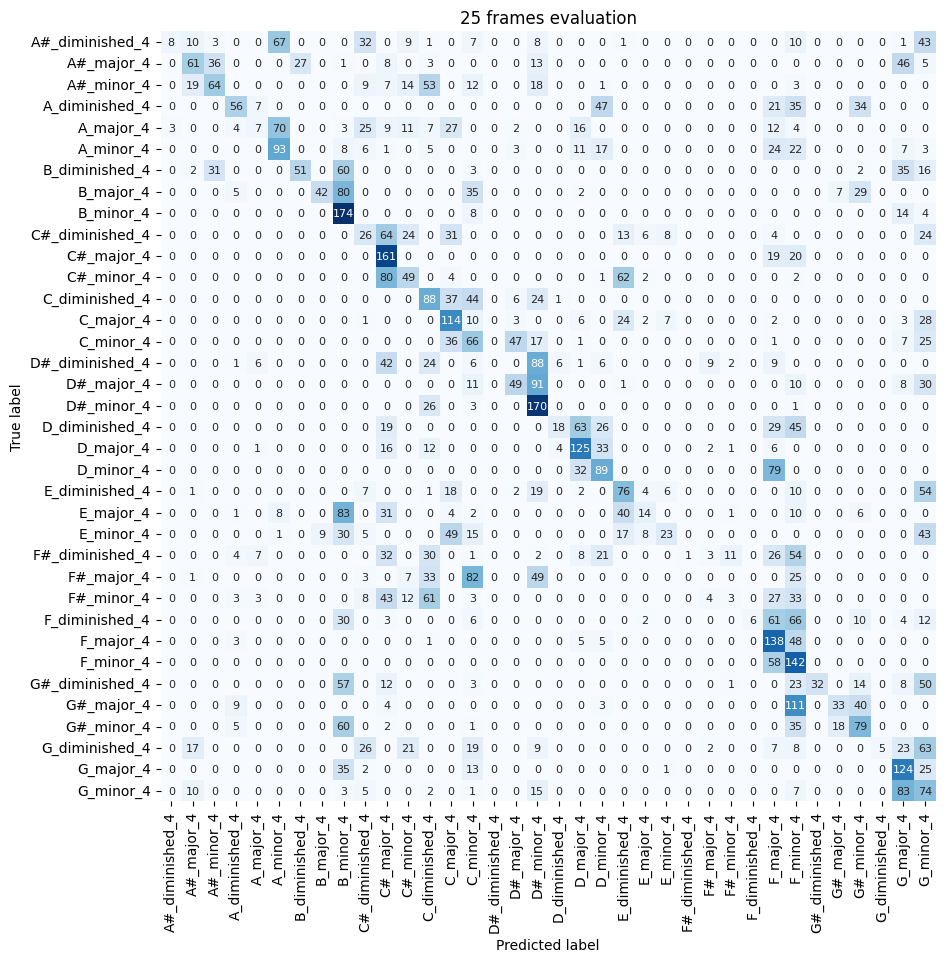

In [8]:
results_25 = evaluate_frames(25)

# Results

In [11]:
from IPython.display import display

results_map = {
    "Original features": original_results,
    "First 150 frames": results_150,
    "First 100 frames": results_100,
    "First 50 frames": results_50,
    "First 25 frames": results_25,
}

evaluation_summary_df = pd.concat(
    [
        result["summary"]
        for result in results_map.values()
    ],
    ignore_index=True,
)

evaluation_summary_table = evaluation_summary_df[[
    "evaluation",
    "input_frames",
    "target_frames",
    "num_samples",
    "accuracy",
    "macro_f1",
    "weighted_f1",
]]

chord_accuracy_frames = []
for evaluation_name, result in results_map.items():
    report_df = result["report"]
    chord_rows = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore").copy()
    chord_rows = chord_rows[["recall", "f1-score", "support"]]
    chord_rows.columns = pd.MultiIndex.from_product([[evaluation_name], chord_rows.columns])
    chord_accuracy_frames.append(chord_rows)

chord_accuracy_table = pd.concat(chord_accuracy_frames, axis=1)
chord_accuracy_table.index.name = "chord"

chord_average_accuracy_table = pd.DataFrame({
    "average_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).mean(axis=1),
    "std_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).std(axis=1),
    "best_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).max(axis=1),
    "worst_accuracy": chord_accuracy_table.xs("recall", axis=1, level=1).min(axis=1),
    "sample_count": chord_accuracy_table.xs("support", axis=1, level=1).sum(axis=1).astype(int),
})

comparison_table = evaluation_summary_table.copy()
comparison_table["input_frames"] = comparison_table["input_frames"].astype(int)
comparison_table["target_frames"] = comparison_table["target_frames"].astype(int)

print("Evaluation summary")
display(comparison_table.round(6))

print("Chord accuracy by evaluation")
display(chord_accuracy_table.round(6))

print("Chord average accuracy summary")
display(chord_average_accuracy_table.round(6))

Evaluation summary


,evaluation,input_frames,target_frames,num_samples,accuracy,macro_f1,weighted_f1
0,188 frames,188,188,7200,1.000000,1.000000,1.000000
1,150 frames,150,188,7200,1.000000,1.000000,1.000000
2,100 frames,100,188,7200,0.997222,0.997225,0.997225
3,50 frames,50,188,7200,0.748750,0.740453,0.740453
4,25 frames,25,188,7200,0.314028,0.267275,0.267275


Chord accuracy by evaluation


Original features                  First 150 frames           \
                           recall f1-score support           recall f1-score   
chord                                                                          
A#_diminished_4               1.0      1.0   200.0              1.0      1.0   
A#_major_4                    1.0      1.0   200.0              1.0      1.0   
A#_minor_4                    1.0      1.0   200.0              1.0      1.0   
A_diminished_4                1.0      1.0   200.0              1.0      1.0   
A_major_4                     1.0      1.0   200.0              1.0      1.0   
A_minor_4                     1.0      1.0   200.0              1.0      1.0   
B_diminished_4                1.0      1.0   200.0              1.0      1.0   
B_major_4                     1.0      1.0   200.0              1.0      1.0   
B_minor_4                     1.0      1.0   200.0              1.0      1.0   
C#_diminished_4               1.0      1.0   200.0              1.0      1.0   
C#_major_4                    1.0      1.0   200.0              1.0      1.0   
C#_minor_4                    1.0      1.0   200.0              1.0      1.0   
C_diminished_4                1.0      1.0   200.0              1.0      1.0   
C_major_4                     1.0      1.0   200.0              1.0      1.0   
C_minor_4                     1.0      1.0   200.0              1.0      1.0   
D#_diminished_4               1.0      1.0   200.0              1.0      1.0   
D#_major_4                    1.0      1.0   200.0              1.0      1.0   
D#_minor_4                    1.0      1.0   200.0              1.0      1.0   
D_diminished_4                1.0      1.0   200.0              1.0      1.0   
D_major_4                     1.0      1.0   200.0              1.0      1.0   
D_minor_4                     1.0      1.0   200.0              1.0      1.0   
E_diminished_4                1.0      1.0   200.0              1.0      1.0   
E_major_4                     1.0      1.0   200.0              1.0      1.0   
E_minor_4                     1.0      1.0   200.0              1.0      1.0   
F#_diminished_4               1.0      1.0   200.0              1.0      1.0   
F#_major_4                    1.0      1.0   200.0              1.0      1.0   
F#_minor_4                    1.0      1.0   200.0              1.0      1.0   
F_diminished_4                1.0      1.0   200.0              1.0      1.0   
F_major_4                     1.0      1.0   200.0              1.0      1.0   
F_minor_4                     1.0      1.0   200.0              1.0      1.0   
G#_diminished_4               1.0      1.0   200.0              1.0      1.0   
G#_major_4                    1.0      1.0   200.0              1.0      1.0   
G#_minor_4                    1.0      1.0   200.0              1.0      1.0   
G_diminished_4                1.0      1.0   200.0              1.0      1.0   
G_major_4                     1.0      1.0   200.0              1.0      1.0   
G_minor_4                     1.0      1.0   200.0              1.0      1.0   

                        First 100 frames                   First 50 frames  \
                support           recall  f1-score support          recall   
chord                                                                        
A#_diminished_4   200.0            0.985  0.992443   200.0           0.520   
A#_major_4        200.0            1.000  1.000000   200.0           0.780   
A#_minor_4        200.0            1.000  0.992556   200.0           0.820   
A_diminished_4    200.0            1.000  1.000000   200.0           0.735   
A_major_4         200.0            1.000  1.000000   200.0           0.575   
A_minor_4         200.0            1.000  1.000000   200.0           0.870   
B_diminished_4    200.0            0.985  0.992443   200.0           0.695   
B_major_4         200.0            1.000  1.000000   200.0           0.870   
B_minor_4         200.0            1.

Chord average accuracy summary


,average_accuracy,std_accuracy,best_accuracy,worst_accuracy,sample_count
chord,,,,,
A#_diminished_4,0.709,0.426855,1.0,0.040,1000
A#_major_4,0.817,0.301654,1.0,0.305,1000
A#_minor_4,0.828,0.294483,1.0,0.320,1000
A_diminished_4,0.803,0.314078,1.0,0.280,1000
A_major_4,0.722,0.425861,1.0,0.035,1000
A_minor_4,0.867,0.231668,1.0,0.465,1000
B_diminished_4,0.787,0.324588,1.0,0.255,1000
B_major_4,0.816,0.343409,1.0,0.210,1000
B_minor_4,0.974,0.058138,1.0,0.870,1000
